In [1]:
import pandas as pd
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = "/Users/kayciebarron/Desktop/LIS501.xlsx"

df_eval = pd.read_excel(file_path, sheet_name="Human Annotation")

df_eval = df_eval[[
    "track_name",
    "artist",
    "raw_lyrics",
    "primary_valence",
    "dominant_emotion",
    "notes"
]]

df_eval["text"] = df_eval["raw_lyrics"].astype(str)

df_eval["primary_valence"] = df_eval["primary_valence"].str.strip()
df_eval["primary_valence"] = df_eval["primary_valence"].replace({
    "Neutral unclear": "Neutral-unclear",
    "Neutral/unclear": "Neutral-unclear"
})

print(df_eval["primary_valence"].value_counts())

primary_valence
Positive           18
Mixed              17
Negative           10
Neutral-unclear     5
Name: count, dtype: int64


In [3]:
df_eval["text"] = df_eval["text"].str.slice(0, 512)

In [4]:
model1 = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment"
)

model2 = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base"
)

Loading weights: 100%|█████████████████████| 201/201 [00:00<00:00, 59153.46it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|█████████████████████| 105/105 [00:00<00:00, 60139.55it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
label_map = {
    "LABEL_0": "Negative",
    "LABEL_1": "Neutral",
    "LABEL_2": "Positive"
}

emotion_to_valence = {
    'joy': 'Positive',
    'surprise': 'Positive',
    'neutral': 'Neutral',
    'sadness': 'Negative',
    'anger': 'Negative',
    'fear': 'Negative',
    'disgust': 'Negative'
}

In [6]:
def run_model1(text):
    result = model1(text)[0]
    return label_map[result['label']]

def run_model2(text):
    result = model2(text)[0]
    emotion = result['label']
    return emotion_to_valence.get(emotion, "Neutral")

print("Running models...")

df_eval["m1_valence"] = df_eval["text"].apply(run_model1)
df_eval["m2_valence"] = df_eval["text"].apply(run_model2)

Running models...


GENERAL MODEL (Twitter RoBERTa) — 4 CLASS:

                 precision    recall  f1-score   support

       Negative       0.33      0.60      0.43        10
Neutral-unclear       0.12      0.60      0.19         5
          Mixed       0.00      0.00      0.00        17
       Positive       0.67      0.22      0.33        18

       accuracy                           0.26        50
      macro avg       0.28      0.36      0.24        50
   weighted avg       0.32      0.26      0.23        50


LYRIC-ADJACENT MODEL (Emotion RoBERTa) — 4 CLASS:

                 precision    recall  f1-score   support

       Negative       0.29      0.80      0.42        10
Neutral-unclear       0.13      0.40      0.20         5
          Mixed       0.00      0.00      0.00        17
       Positive       0.29      0.11      0.16        18

       accuracy                           0.24        50
      macro avg       0.18      0.33      0.20        50
   weighted avg       0.17      0.24      0.

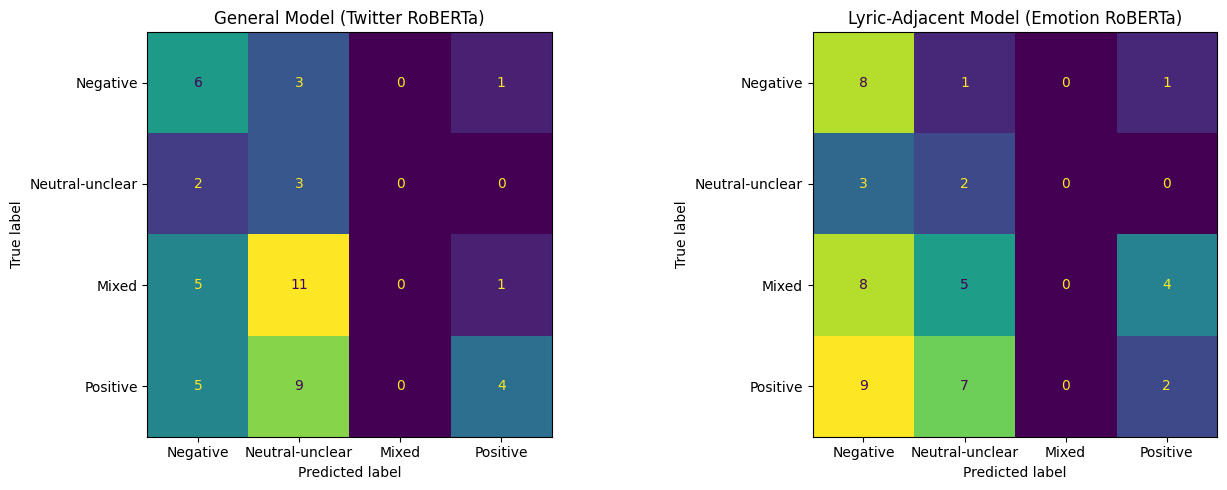

Total songs: 50
Model 1 exact 4-class errors: 37
Model 2 exact 4-class errors: 38
Both models wrong (4-class): 34
Model 2 better cases (4-class exact match): 3
Model 1 better cases (4-class exact match): 4

--- Sample misclassified examples ---



,track_name,artist,primary_valence,m1_valence_4class,m2_valence_4class,dominant_emotion,notes
0,Codeine Crazy,Future,Mixed,Neutral-unclear,Neutral-unclear,"pride/confidence, sadness/loss, resilience/def...",addiction framed positively (luxury + success)...
1,Shake That,Eminem,Positive,Negative,Negative,"joy/celebration, pride/confidence",party/club context; explicit language may bias...
2,Location (feat. Burna Boy),Dave,Positive,Neutral-unclear,Neutral-unclear,"pride/confidence, joy/celebration, love/affection",success narrative (“came a long way”) with sla...
3,Let Me Calm Down (feat. J. Cole),Nicki Minaj,Mixed,Neutral-unclear,Negative,"sadness/loss, anger/aggression, love/affection",conflicting emotions in relationships; polarit...
4,KOD,J. Cole,Mixed,Negative,Negative,"pride/confidence, anger/aggression, sadness/loss",drug culture critique vs glorification; negati...
5,Funky Friday,Dave,Positive,Neutral-unclear,Neutral-unclear,"joy/celebration, pride/confidence",NaN
7,Mona Lisa (feat. Kendrick Lamar),Kendrick Lamar,Negative,Neutral-unclear,Neutral-unclear,"anger/aggression, fear/anxiety",deception narrative; violent + manipulative th...
9,Home Alone (with J. Cole),J. Cole,Mixed,Neutral-unclear,Negative,"sadness/loss, resilience/defiance, love/affection",trauma + growth narrative; reflective tone; ch...
10,Plain Jane REMIX (feat. Nicki Minaj),Nicki Minaj,Positive,Neutral-unclear,Negative,"pride/confidence, joy/celebration",likely polarity inversion issues
11,"One Mic, One Gun",Nas,Positive,Neutral-unclear,Neutral-unclear,"pride/confidence, resilience/defiance, anger/a...","(“GOAT,” “I opened a lane”) → positive sentime..."



--- Error type distribution (both models wrong) ---

error_type
other                                 9
metaphorical/performative language    8
polarity inversion                    7
slang/AAVE                            6
narrative voice                       2
irony/sarcasm                         2
Name: count, dtype: int64
Working directory: /Users/kayciebarron/LIS501

Saved files:
- model_results_4class.txt
- confusion_matrices_4class.pdf
- model_predictions_4class.csv
- both_models_wrong_4class.csv
- and copies on Desktop


In [21]:
# -----------------------------
# 4-CLASS EVALUATION
# -----------------------------

# Standardize model outputs so they match the human label names
df_eval["m1_valence_4class"] = df_eval["m1_valence"].replace({
    "Neutral": "Neutral-unclear"
})

df_eval["m2_valence_4class"] = df_eval["m2_valence"].replace({
    "Neutral": "Neutral-unclear"
})

label_order = ["Negative", "Neutral-unclear", "Mixed", "Positive"]

report1_4class = classification_report(
    df_eval["primary_valence"],
    df_eval["m1_valence_4class"],
    labels=label_order,
    zero_division=0
)

report2_4class = classification_report(
    df_eval["primary_valence"],
    df_eval["m2_valence_4class"],
    labels=label_order,
    zero_division=0
)

print("GENERAL MODEL (Twitter RoBERTa) — 4 CLASS:\n")
print(report1_4class)

print("\nLYRIC-ADJACENT MODEL (Emotion RoBERTa) — 4 CLASS:\n")
print(report2_4class)


# -----------------------------
# 4-CLASS CONFUSION MATRICES
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ["m1_valence_4class", "m2_valence_4class"],
    [
        "General Model (Twitter RoBERTa)",
        "Lyric-Adjacent Model (Emotion RoBERTa)"
    ]
):
    cm = confusion_matrix(
        df_eval["primary_valence"],
        df_eval[col],
        labels=label_order
    )

    ConfusionMatrixDisplay(
        cm,
        display_labels=label_order
    ).plot(ax=ax, colorbar=False)

    ax.set_title(title)

plt.tight_layout()
plt.savefig("confusion_matrices_4class.pdf")
plt.show()


# -----------------------------
# ERROR ANALYSIS: EXACT 4-CLASS FAILURES
# -----------------------------
df_eval["m1_error_4class"] = df_eval["primary_valence"] != df_eval["m1_valence_4class"]
df_eval["m2_error_4class"] = df_eval["primary_valence"] != df_eval["m2_valence_4class"]

both_wrong = df_eval[
    df_eval["m1_error_4class"] & df_eval["m2_error_4class"]
].copy()

df_eval["model2_better_4class"] = (
    (df_eval["m2_valence_4class"] == df_eval["primary_valence"]) &
    (df_eval["m1_valence_4class"] != df_eval["primary_valence"])
)

df_eval["model1_better_4class"] = (
    (df_eval["m1_valence_4class"] == df_eval["primary_valence"]) &
    (df_eval["m2_valence_4class"] != df_eval["primary_valence"])
)

print("Total songs:", len(df_eval))
print("Model 1 exact 4-class errors:", df_eval["m1_error_4class"].sum())
print("Model 2 exact 4-class errors:", df_eval["m2_error_4class"].sum())
print("Both models wrong (4-class):", len(both_wrong))
print("Model 2 better cases (4-class exact match):", df_eval["model2_better_4class"].sum())
print("Model 1 better cases (4-class exact match):", df_eval["model1_better_4class"].sum())

print("\n--- Sample misclassified examples ---\n")
display(
    both_wrong[
        [
            "track_name",
            "artist",
            "primary_valence",
            "m1_valence_4class",
            "m2_valence_4class",
            "dominant_emotion",
            "notes"
        ]
    ].head(10)
)


# -----------------------------
# SIMPLE NOTE-PATTERN DETECTION
# -----------------------------
def detect_feature(note):
    note = str(note).lower()

    if any(w in note for w in ["polarity", "framed positively", "negative language used positively", "positive in context"]):
        return "polarity inversion"
    elif any(w in note for w in ["slang", "aave", "dialect", "colloquial"]):
        return "slang/AAVE"
    elif any(w in note for w in ["irony", "sarcasm", "sarcastic"]):
        return "irony/sarcasm"
    elif any(w in note for w in ["metaphor", "figurative", "performative", "persona"]):
        return "metaphorical/performative language"
    elif any(w in note for w in ["mixed", "conflict", "conflicting", "multiple emotions", "ambivalent"]):
        return "mixed emotional tone"
    elif any(w in note for w in ["narrative", "storytelling", "speaker", "narrative voice"]):
        return "narrative voice"
    else:
        return "other"

both_wrong["error_type"] = both_wrong["notes"].apply(detect_feature)

print("\n--- Error type distribution (both models wrong) ---\n")
print(both_wrong["error_type"].value_counts())


# -----------------------------
# SAVE OUTPUTS
# -----------------------------
import os

print("Working directory:", os.getcwd())
desktop_path = "/Users/kayciebarron/Desktop/"

# Save reports
with open("model_results_4class.txt", "w") as f:
    f.write("GENERAL MODEL (Twitter RoBERTa) — 4 CLASS\n")
    f.write(report1_4class)
    f.write("\n\n")
    f.write("LYRIC-ADJACENT MODEL (Emotion RoBERTa) — 4 CLASS\n")
    f.write(report2_4class)
    f.write("\n\n")
    f.write("Total songs: " + str(len(df_eval)) + "\n")
    f.write("Model 1 exact 4-class errors: " + str(df_eval["m1_error_4class"].sum()) + "\n")
    f.write("Model 2 exact 4-class errors: " + str(df_eval["m2_error_4class"].sum()) + "\n")
    f.write("Both models wrong (4-class): " + str(len(both_wrong)) + "\n")
    f.write("Model 2 better cases (4-class exact match): " + str(df_eval["model2_better_4class"].sum()) + "\n")
    f.write("Model 1 better cases (4-class exact match): " + str(df_eval["model1_better_4class"].sum()) + "\n")
    f.write("\nError type distribution:\n")
    f.write(str(both_wrong["error_type"].value_counts()))

with open(desktop_path + "model_results_4class.txt", "w") as f:
    f.write("GENERAL MODEL (Twitter RoBERTa) — 4 CLASS\n")
    f.write(report1_4class)
    f.write("\n\n")
    f.write("LYRIC-ADJACENT MODEL (Emotion RoBERTa) — 4 CLASS\n")
    f.write(report2_4class)
    f.write("\n\n")
    f.write("Total songs: " + str(len(df_eval)) + "\n")
    f.write("Model 1 exact 4-class errors: " + str(df_eval["m1_error_4class"].sum()) + "\n")
    f.write("Model 2 exact 4-class errors: " + str(df_eval["m2_error_4class"].sum()) + "\n")
    f.write("Both models wrong (4-class): " + str(len(both_wrong)) + "\n")
    f.write("Model 2 better cases (4-class exact match): " + str(df_eval["model2_better_4class"].sum()) + "\n")
    f.write("Model 1 better cases (4-class exact match): " + str(df_eval["model1_better_4class"].sum()) + "\n")
    f.write("\nError type distribution:\n")
    f.write(str(both_wrong["error_type"].value_counts()))

# Save full predictions
df_eval_renamed = df_eval.rename(columns={
    "m1_valence": "general_model_valence_raw",
    "m2_valence": "lyric_model_valence_raw",
    "m1_valence_4class": "general_model_valence_4class",
    "m2_valence_4class": "lyric_model_valence_4class"
})

df_eval_renamed.to_csv("model_predictions_4class.csv", index=False)
df_eval_renamed.to_csv(desktop_path + "model_predictions_4class.csv", index=False)

both_wrong.to_csv("both_models_wrong_4class.csv", index=False)
both_wrong.to_csv(desktop_path + "both_models_wrong_4class.csv", index=False)

print("\nSaved files:")
print("- model_results_4class.txt")
print("- confusion_matrices_4class.pdf")
print("- model_predictions_4class.csv")
print("- both_models_wrong_4class.csv")
print("- and copies on Desktop")